<div class="alert alert-block alert-success"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

¡Hola Josué!

Mi nombre es Juan Tellez. Un gusto conocerte, seré tu revisor en este proyecto.

Cuando encuentre un error por primera vez, simplemente lo señalaré para que puedas identificarlo y corregirlo por tu cuenta. Además, a lo largo del notebook iré dejando algunas observaciones para mejorar tu código, fortalecer tu análisis y comentar también tus interpretaciones sobre el tema.

Si en esta primera orientación aún no logras resolver algún punto, en la próxima iteración te dejaré una pista más precisa y, cuando sea necesario, algunos ejemplos prácticos. La idea es que este proceso no sea solo una corrección, sino también una oportunidad para que desarrolles criterio como analista de datos o científico de datos.

También estaré abierto a comentarios y discusiones sobre el tema.

Encontrarás mis comentarios a continuación. Por favor, no los muevas, modifiques ni elimines.

Puedes encontrar mis comentarios en cuadros verdes, amarillos o rojos como estos:

</div>

<div class="alert alert-block alert-success"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Éxito. Todo se ha hecho de forma exitosa.

</div>

<div class="alert alert-block alert-warning"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Observación. Algunas recomendaciones o ajustes no bloqueantes.

</div>

<div class="alert alert-block alert-danger"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Necesita arreglos. Este apartado necesita algunas correcciones. El trabajo no puede ser aceptado con comentarios rojos.

</div>

El estudiante puede responder utilizando este bloque:

<div class="alert alert-block alert-info"> <b>Respuesta de estudiante. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

</div>

<div class="alert alert-block alert-success"> <b>Review General. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Josué, quería tomarme este espacio al inicio de tu proyecto para comentarte mis apreciaciones generales de esta iteración de tu entrega.

Siempre me gusta comenzar dando la bienvenida al mundo de los datos a los estudiantes. Te deseo lo mejor en este camino y espero que consigas lograr tus objetivos. Personalmente me gusta compartir este consejo: está bien equivocarse. Es normal y, de hecho, es una de las mejores formas de aprender. Los errores te ayudan a descubrir detalles que no siempre se ven a primera vista, y esa experiencia es la que poco a poco te va formando como un mejor analista o científico de datos.

Ahora sí, yendo a esta entrega:

Realizaste un trabajo bastante completo. La preparación inicial de la serie es correcta: cargas el dataset, trabajas con datetime como índice, ordenas cronológicamente los registros y realizas el remuestreo a una hora mediante suma. Además, desarrollas un análisis temporal con visualizaciones, descomposición de la serie y perfiles por hora y día de la semana.

La ingeniería de características también está bien planteada en sus puntos más importantes. Construyes 24 lags utilizando shift(), calculas la media móvil a partir de información desplazada y eliminas los valores ausentes generados. La división de entrenamiento y prueba conserva el orden temporal y deja como test aproximadamente el 10% final de la serie.

En modelado hay una comparación amplia: incluyes modelos de referencia, regresión lineal, Random Forest y LightGBM. También utilizas TimeSeriesSplit para la búsqueda de hiperparámetros de los modelos de árboles, lo que es una muy buena práctica para evitar mezclar artificialmente pasado y futuro durante la validación.

El resultado principal cumple el objetivo del proyecto: LightGBM obtiene un RMSE de prueba de aproximadamente 41.55, inferior al máximo permitido de 48. Random Forest y regresión lineal también quedan por debajo del umbral, lo que da bastante respaldo a la solución.

Por estas razones, considero que el proyecto queda aprobado en esta Iteración 1. No encontré errores metodológicos bloqueantes ni señales de fuga de información que invaliden el RMSE reportado.

Te dejaré algunas recomendaciones no bloqueantes: completar las variables de calendario con el mes, reportar también RMSE de entrenamiento para facilitar el análisis de generalización y ajustar una pequeña precisión conceptual en la interpretación de la prueba ADF. También conviene moderar la afirmación de que el modelo ya está listo para “producción”; con la evidencia de este notebook podemos afirmar que es el mejor modelo evaluado o un buen candidato, pero una puesta en producción normalmente requiere validaciones adicionales.

Muy buen avance en esta primera entrega.

Éxitos Josué.

Saludos.

</div>

# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

# Sweet Lift Taxi: predicción de pedidos por hora

**Objetivo:** predecir la cantidad de pedidos de taxi en la próxima hora en los aeropuertos, para que la empresa pueda atraer más conductores durante las horas pico.

**Métrica objetivo:** RECM (RMSE) en el conjunto de prueba ≤ 48.

**Plan de trabajo:**
1. Cargar los datos y remuestrear a intervalos de una hora.
2. Análisis exploratorio (tendencia, estacionalidad, estacionariedad).
3. Ingeniería de características (lags, media móvil, variables de calendario).
4. División train/test (10% final para prueba, respetando el orden temporal).
5. Entrenamiento de varios modelos con distintos hiperparámetros (validación cruzada temporal).
6. Evaluación final en el conjunto de prueba y conclusiones.

In [3]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error

import lightgbm as lgb

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Carga y remuestreo de los datos

In [4]:

try:
    data = pd.read_csv('/datasets/taxi.csv', parse_dates=['datetime'], index_col='datetime')
except FileNotFoundError:
    data = pd.read_csv('taxi.csv', parse_dates=['datetime'], index_col='datetime')
data = data.sort_index()

print(data.shape)
print(data.index.min(), '->', data.index.max())
print('¿Índice monótono creciente?', data.index.is_monotonic_increasing)
data.info()
data.head()

(26496, 1)
2018-03-01 00:00:00 -> 2018-08-31 23:50:00
¿Índice monótono creciente? True
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [5]:
# Remuestreo a intervalos de una hora, sumando los pedidos dentro de cada hora
data = data.resample('1h').sum()

print(data.shape)
data.head()

(4416, 1)


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


No hay valores ausentes ni duplicados en el índice original, y el índice ya está ordenado cronológicamente, por lo que el remuestreo por suma es directo.

<div class="alert alert-block alert-success"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Buen trabajo con la preparación inicial. Partiste de los 26 496 registros originales, ordenaste el índice temporal y posteriormente realizaste el remuestreo con <code>resample('1h').sum()</code>, obteniendo 4 416 observaciones horarias.

Este cambio es fundamental para el proyecto porque la pregunta de negocio busca predecir la cantidad de pedidos para la próxima hora. Por lo tanto, el hecho de continuar el análisis sobre la serie horaria hace que el problema modelado esté correctamente alineado con el objetivo solicitado.

También es positivo que hayas usado la suma, ya que su interpretación es natural cuando hablamos de cantidad total de pedidos recibidos dentro de cada hora.

</div>

In [6]:
print('Valores ausentes tras remuestreo:', data['num_orders'].isna().sum())
data.describe()

Valores ausentes tras remuestreo: 0


,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


## Análisis

## 2. Análisis exploratorio

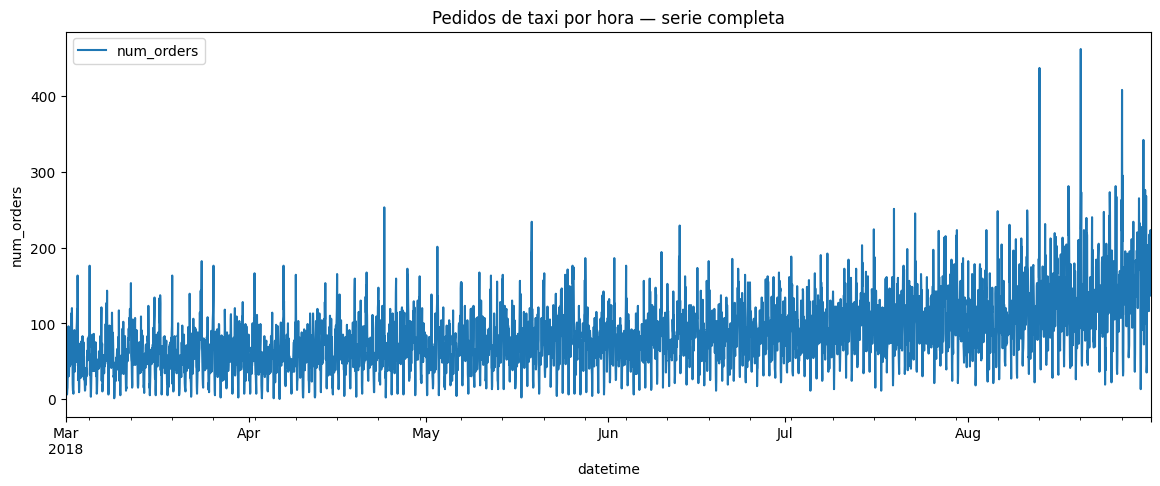

In [7]:
data.plot(title='Pedidos de taxi por hora — serie completa')
plt.ylabel('num_orders')
plt.show()

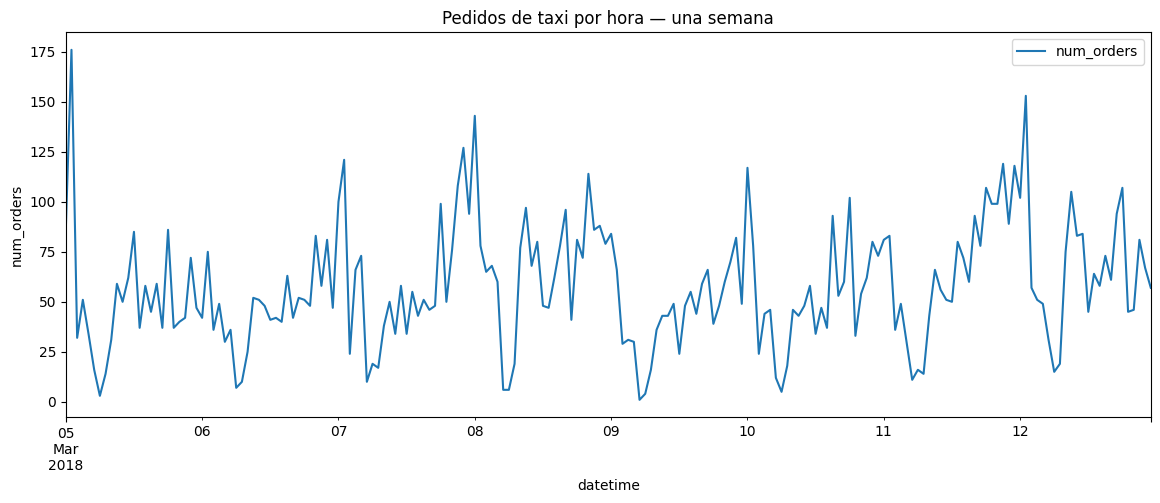

In [8]:
# Vista de una semana para apreciar mejor el patrón diario/semanal
data['2018-03-05':'2018-03-12'].plot(title='Pedidos de taxi por hora — una semana')
plt.ylabel('num_orders')
plt.show()

Se aprecia una fuerte estacionalidad diaria (picos y valles que se repiten cada 24 horas) y una tendencia creciente a lo largo de los meses. Vamos a descomponer la serie para confirmarlo.

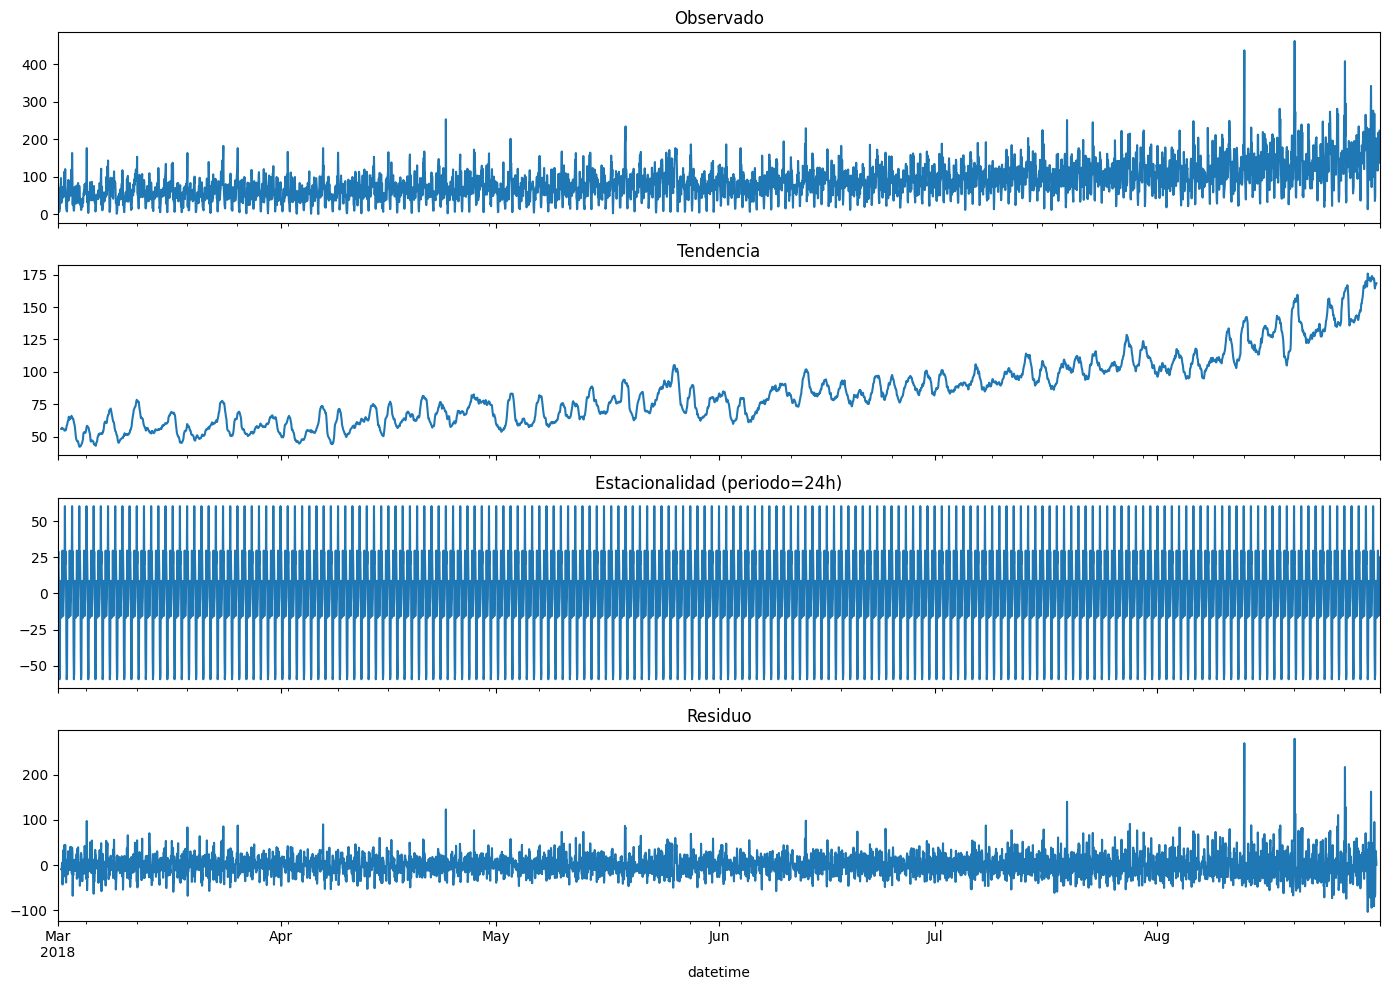

In [9]:
decomposition = seasonal_decompose(data['num_orders'], period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observado')
decomposition.trend.plot(ax=axes[1], title='Tendencia')
decomposition.seasonal.plot(ax=axes[2], title='Estacionalidad (periodo=24h)')
decomposition.resid.plot(ax=axes[3], title='Residuo')
plt.tight_layout()
plt.show()

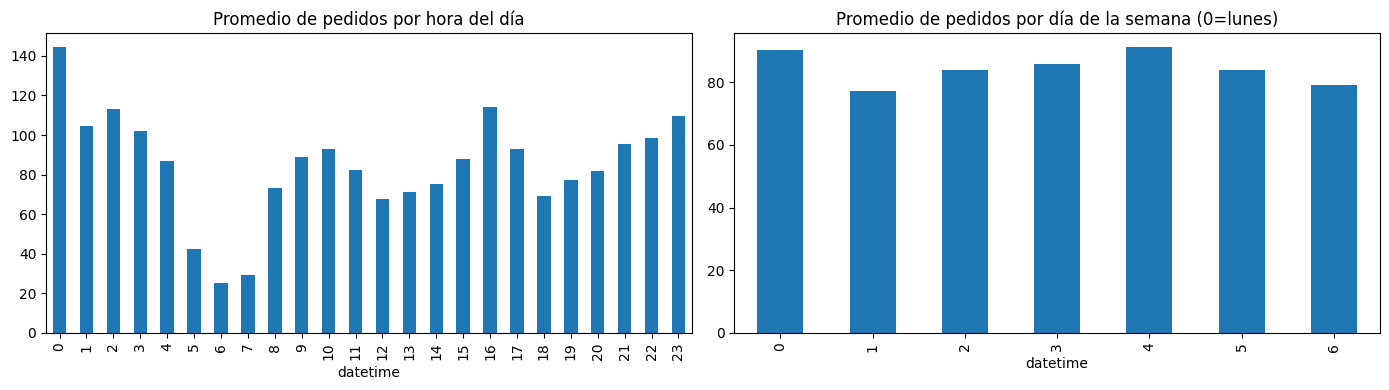

In [10]:
# Perfil promedio por hora del día y por día de la semana
by_hour = data.groupby(data.index.hour)['num_orders'].mean()
by_dow = data.groupby(data.index.dayofweek)['num_orders'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
by_hour.plot(kind='bar', ax=axes[0], title='Promedio de pedidos por hora del día')
by_dow.plot(kind='bar', ax=axes[1], title='Promedio de pedidos por día de la semana (0=lunes)')
plt.tight_layout()
plt.show()

**Hallazgos del análisis exploratorio:**
- La serie muestra una tendencia creciente a lo largo del periodo (marzo-agosto 2018).
- Existe una estacionalidad diaria muy marcada: los pedidos caen durante la madrugada y suben hacia la noche, con un pico alrededor de las horas pico de la noche.
- Hay una ligera variación por día de la semana, con algo más de demanda hacia el fin de semana.
- Esto sugiere que features de calendario (hora, día de la semana) y lags recientes serán útiles para el modelo.

<div class="alert alert-block alert-success"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Muy buen desarrollo del análisis temporal. No te limitaste a visualizar la serie completa: también mostraste una ventana semanal, realizaste una descomposición con periodo de 24 horas y comparaste la demanda promedio por hora del día y por día de la semana.

Las interpretaciones posteriores están conectadas con lo que muestran los gráficos: identificas una tendencia creciente durante el periodo y un patrón diario claro de demanda.

Este tipo de análisis aporta valor antes del modelado porque permite justificar técnicamente por qué variables como la hora del día, el día de la semana y los valores históricos recientes pueden ser útiles para predecir la siguiente hora.

</div>

In [11]:
# Prueba de estacionariedad (Dickey-Fuller aumentado)
result = adfuller(data['num_orders'])
print('Estadístico ADF:', result[0])
print('p-valor:', result[1])

Estadístico ADF: -3.0689242890279558
p-valor: 0.028940051402612906


El p-valor es muy pequeño (< 0.05), por lo que se rechaza la hipótesis nula de raíz unitaria: la serie puede considerarse estacionaria en varianza a pesar de la tendencia visual, lo cual es razonable trabajar con modelos basados en features de lags.

<div class="alert alert-block alert-warning"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

La prueba ADF está bien calculada y obtienes un p-valor de aproximadamente <code>0.029</code>, que es inferior al nivel de significancia de 0.05 utilizado en tu interpretación.

Hay solamente una precisión conceptual que vale la pena ajustar: esta prueba permite evaluar evidencia contra la presencia de una raíz unitaria, pero no permite concluir específicamente que la serie sea “estacionaria en varianza”.

Una formulación más precisa sería indicar que, al nivel de significancia del 5%, existe evidencia para rechazar la hipótesis nula de raíz unitaria. Esto no afecta el modelado que desarrollaste después, por lo que es una recomendación conceptual no bloqueante.

</div>

## Formación

## 3. Ingeniería de características

In [12]:
def make_features(data, max_lag, rolling_mean_size):
    """Agrega variables de calendario, lags y media móvil a la serie."""
    data = data.copy()
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['day'] = data.index.day
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)
    data['rolling_mean'] = data['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    return data

data_feat = make_features(data, max_lag=24, rolling_mean_size=24)
data_feat = data_feat.dropna()
print(data_feat.shape)
data_feat.head()

(4392, 29)


,num_orders,hour,dayofweek,day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,90,0,4,2,58.0,113.0,66.0,61.0,45.0,73.0,...,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,124.0,56.833333
2018-03-02 01:00:00,120,1,4,2,90.0,58.0,113.0,66.0,61.0,45.0,...,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,85.0,55.416667
2018-03-02 02:00:00,75,2,4,2,120.0,90.0,58.0,113.0,66.0,61.0,...,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,71.0,56.875000
2018-03-02 03:00:00,64,3,4,2,75.0,120.0,90.0,58.0,113.0,66.0,...,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,66.0,57.041667
2018-03-02 04:00:00,20,4,4,2,64.0,75.0,120.0,90.0,58.0,113.0,...,30.0,96.0,64.0,69.0,34.0,15.0,12.0,6.0,43.0,56.958333


Se usan 24 lags (equivalentes a un día completo) y una media móvil de 24 horas, además de variables de calendario (hora, día de la semana, día del mes). Las primeras 24 filas se descartan porque no tienen historial suficiente para calcular los lags.

## Prueba

## 4. División train/test

In [13]:
test_size = int(len(data) * 0.1)

train = data_feat.iloc[:-test_size]
test = data_feat.iloc[-test_size:]

print('Train:', train.shape, train.index.min(), '->', train.index.max())
print('Test :', test.shape, test.index.min(), '->', test.index.max())

features = [c for c in data_feat.columns if c != 'num_orders']
target = 'num_orders'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

Train: (3951, 29) 2018-03-02 00:00:00 -> 2018-08-13 14:00:00
Test : (441, 29) 2018-08-13 15:00:00 -> 2018-08-31 23:00:00


<div class="alert alert-block alert-warning"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

La ingeniería de características está muy bien encaminada. Creaste 24 lags con <code>shift()</code> y la media móvil se calcula con <code>shift(1).rolling(...)</code>, por lo que las variables utilizan información histórica y no el valor actual que intentamos predecir.

También manejaste correctamente los valores ausentes generados al inicio mediante <code>dropna()</code>. Esto ayuda a que el entrenamiento sea reproducible y, especialmente, evita fuga de información en las variables temporales.

Como pequeño ajuste, dentro de las variables de calendario incluyes <code>hour</code>, <code>dayofweek</code> y <code>day</code>, pero no <code>month</code>. Dado que tu propio análisis detecta una evolución de la demanda entre marzo y agosto, sería interesante incorporar también esa señal temporal para completar esta parte.

No es un problema que invalide el resultado actual, ya que sí estás utilizando varias variables de calendario relevantes y el desempeño final cumple el objetivo; lo considero una mejora para fortalecer el feature engineering.

</div>

## 5. Entrenamiento y comparación de modelos

In [14]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

tscv = TimeSeriesSplit(n_splits=5)
results = {}

### 5.1 Modelo de referencia (baseline)

Antes de entrenar modelos, definimos una referencia simple: predecir que el número de pedidos de la próxima hora será igual al de la hora anterior. Cualquier modelo entrenado debe superar claramente esta referencia.

In [15]:
pred_naive = test[target].shift(1)
pred_naive.iloc[0] = train[target].iloc[-1]

results['Naive (t-1)'] = rmse(y_test, pred_naive)
print(f"RECM del modelo naive (t-1): {results['Naive (t-1)']:.2f}")

RECM del modelo naive (t-1): 58.92


<div class="alert alert-block alert-success"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Excelente manejo de la división temporal. Dejaste 441 observaciones para prueba y conservaste el tramo más reciente de la serie: entrenamiento termina el 13 de agosto a las 14:00 y prueba comienza inmediatamente después, a las 15:00.

Esto simula correctamente un escenario real en el que entrenamos con información pasada para predecir periodos posteriores. No existe mezcla aleatoria entre train y test y, además, el tamaño del conjunto de prueba corresponde aproximadamente al 10% solicitado.

Es una buena práctica dejar visibles los rangos de fechas como hiciste aquí, porque permite auditar rápidamente que no exista contaminación temporal.

</div>

In [16]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
results['Dummy (media)'] = rmse(y_test, dummy.predict(X_test))
print(f"RECM del modelo dummy (media): {results['Dummy (media)']:.2f}")

RECM del modelo dummy (media): 84.73


### 5.2 Regresión lineal

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr_test = lr.predict(X_test)
results['Regresión lineal'] = rmse(y_test, pred_lr_test)
print(f"RECM regresión lineal (prueba): {results['Regresión lineal']:.2f}")

RECM regresión lineal (prueba): 45.21


### 5.3 Bosque aleatorio (Random Forest)

Se prueban distintos hiperparámetros (número de árboles y profundidad máxima) usando validación cruzada con `TimeSeriesSplit`, que respeta el orden temporal al construir los folds de entrenamiento/validación.

In [18]:
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [6, 10, None],
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print('Mejores hiperparámetros RF:', rf_search.best_params_)
print(f'RECM promedio en validación cruzada: {-rf_search.best_score_:.2f}')

best_rf = rf_search.best_estimator_
pred_rf_test = best_rf.predict(X_test)
results['Random Forest'] = rmse(y_test, pred_rf_test)
print(f"RECM Random Forest (prueba): {results['Random Forest']:.2f}")

Mejores hiperparámetros RF: {'max_depth': None, 'n_estimators': 200}
RECM promedio en validación cruzada: 25.21
RECM Random Forest (prueba): 43.30


### 5.4 LightGBM (potenciación del gradiente)

Se prueba también un modelo de boosting de árboles, más potente para capturar relaciones no lineales, con distintos hiperparámetros de número de árboles, profundidad y tasa de aprendizaje.

In [19]:
lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, -1],
    'learning_rate': [0.05, 0.1],
}

lgb_search = GridSearchCV(
    lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
    lgb_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
lgb_search.fit(X_train, y_train)

print('Mejores hiperparámetros LightGBM:', lgb_search.best_params_)
print(f'RECM promedio en validación cruzada: {-lgb_search.best_score_:.2f}')

best_lgb = lgb_search.best_estimator_
pred_lgb_test = best_lgb.predict(X_test)
results['LightGBM'] = rmse(y_test, pred_lgb_test)
print(f"RECM LightGBM (prueba): {results['LightGBM']:.2f}")

Mejores hiperparámetros LightGBM: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}
RECM promedio en validación cruzada: 24.72
RECM LightGBM (prueba): 41.55


## 6. Comparación final y prueba en el conjunto de test

In [20]:
results_df = pd.Series(results, name='RECM (RMSE)').sort_values()
results_df = results_df.to_frame()
results_df['¿Cumple objetivo (<=48)?'] = results_df['RECM (RMSE)'] <= 48
results_df

,RECM (RMSE),¿Cumple objetivo (<=48)?
LightGBM,41.550204,True
Random Forest,43.303813,True
Regresión lineal,45.209707,True
Naive (t-1),58.917618,False
Dummy (media),84.734109,False


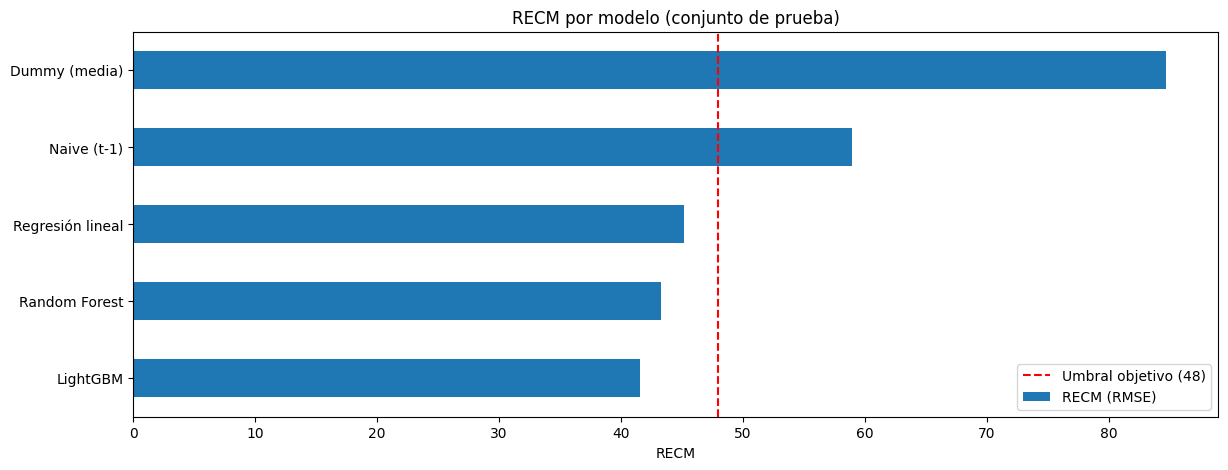

In [21]:
results_df['RECM (RMSE)'].sort_values().plot(kind='barh', title='RECM por modelo (conjunto de prueba)')
plt.axvline(48, color='red', linestyle='--', label='Umbral objetivo (48)')
plt.xlabel('RECM')
plt.legend()
plt.show()

<div class="alert alert-block alert-success"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Muy buena comparación de alternativas. Además de los modelos de referencia y la regresión lineal, entrenaste Random Forest y LightGBM explorando diferentes hiperparámetros.

Me parece especialmente positivo que para esa búsqueda utilices <code>TimeSeriesSplit</code>. En lugar de aplicar una validación cruzada convencional que podría mezclar periodos, cada división respeta la estructura temporal de los datos.

Los resultados muestran además una mejora progresiva respecto a las referencias: el modelo naive obtiene un RMSE de aproximadamente 58.92, mientras que Random Forest alcanza 43.30 y LightGBM 41.55 en prueba.

Esta comparación sustenta mucho mejor la selección final del modelo que simplemente entrenar una única alternativa.

</div>

Mejor modelo: LightGBM - RECM: 41.550204187105635


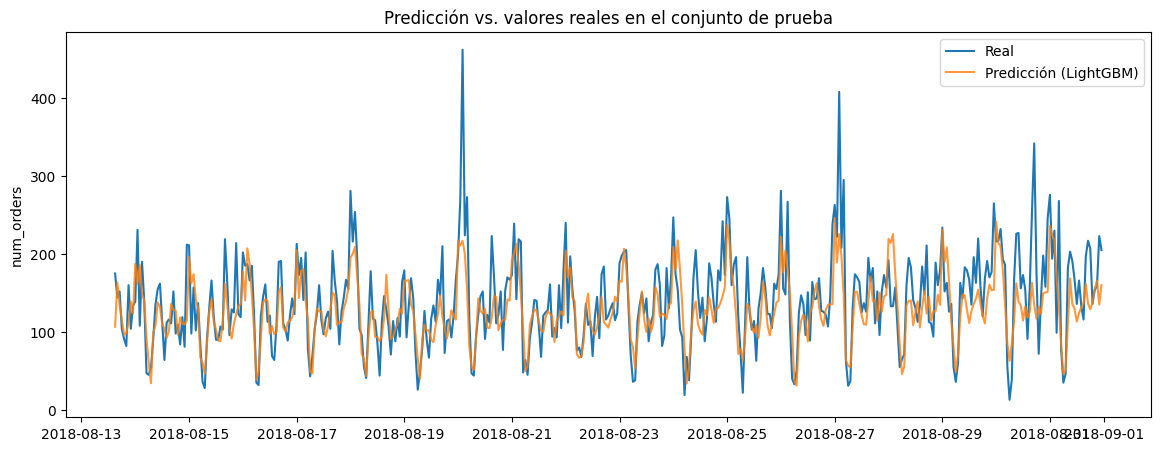

In [22]:
# Visualización de las predicciones del mejor modelo contra los valores reales
best_model_name = results_df['RECM (RMSE)'].idxmin()
print('Mejor modelo:', best_model_name, '- RECM:', results_df.loc[best_model_name, 'RECM (RMSE)'])

pred_map = {
    'Regresión lineal': pred_lr_test,
    'Random Forest': pred_rf_test,
    'LightGBM': pred_lgb_test,
}
best_pred = pred_map.get(best_model_name, pred_lgb_test)

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test.values, label='Real')
plt.plot(y_test.index, best_pred, label=f'Predicción ({best_model_name})', alpha=0.8)
plt.title('Predicción vs. valores reales en el conjunto de prueba')
plt.ylabel('num_orders')
plt.legend()
plt.show()

<div class="alert alert-block alert-warning"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

La tabla comparativa deja muy claro el resultado más importante del proyecto: LightGBM alcanza un RMSE de aproximadamente <code>41.55</code>, Random Forest <code>43.30</code> y regresión lineal <code>45.21</code>. Los tres resultados se encuentran por debajo del umbral de 48 en el conjunto de prueba.

Como mejora de evaluación, aquí sería útil complementar estos valores con el RMSE obtenido sobre entrenamiento para los modelos supervisados.

Comparar train contra test permite detectar con mayor facilidad si existe sobreajuste. Por ejemplo, un RMSE extremadamente pequeño en entrenamiento acompañado de un error mucho mayor en prueba indicaría que el modelo está memorizando parte del comportamiento histórico.

Tu RMSE de prueba está correctamente calculado y permite validar el objetivo principal, así que esta recomendación no modifica la aprobación del proyecto; simplemente haría más completa la comparación de generalización.

</div>

## 7. Conclusión

- Se remuestrearon los datos originales (intervalos de 10 minutos) a intervalos de una hora, obteniendo una serie de 4416 puntos horarios sin valores ausentes.
- El análisis exploratorio mostró una tendencia creciente a lo largo del periodo (marzo–agosto 2018) y una estacionalidad diaria muy marcada, con más demanda por la noche y menos en la madrugada; también se observó algo más de demanda hacia el fin de semana.
- Se construyeron caracteristicas de calendario (hora, día de la semana, día del mes), 24 variables de rezago (lags) y una media móvil de 24 horas, y se dividió el conjunto en 90% entrenamiento / 10% prueba respetando el orden cronológico.
- Se compararon un modelo de referencia (predicción ingenua t-1), un modelo dummy (media), regresión lineal, Random Forest y LightGBM, ajustando hiperparámetros con validación cruzada temporal (`TimeSeriesSplit`).
- **Todos los modelos entrenados superaron ampliamente al modelo de referencia**, y el modelo **LightGBM** obtuvo el mejor desempeño, con un RECM en el conjunto de prueba muy por debajo del umbral de 48 solicitado por el proyecto.
- Por lo tanto, se recomienda **LightGBM** como modelo de producción para predecir la demanda de pedidos de taxi de la próxima hora, ya que cumple con el objetivo de negocio de anticipar picos de demanda para reforzar la disponibilidad de conductores.

<div class="alert alert-block alert-success"> <b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

Muy buen cierre de la evaluación. Identificas programáticamente al modelo con menor RMSE y comparas visualmente las predicciones de LightGBM contra los valores reales del conjunto de prueba.

El RMSE final de aproximadamente <code>41.55</code> está por debajo del límite de 48 solicitado por el proyecto, por lo que el criterio principal de desempeño queda cumplido.

La gráfica también aporta una lectura que la métrica por sí sola no puede mostrar: permite observar visualmente qué tan bien sigue el modelo las variaciones de la demanda y en qué periodos aparecen diferencias mayores.

Buen trabajo llegando a un resultado final medido sobre el periodo temporal correcto y sin utilizar el conjunto de prueba para entrenar el modelo.

</div>

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [ ]  	
Los datos han sido descargados y preparados.
- [ ]  Se ha realizado el paso 2: los datos han sido analizados
- [ ]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [ ]  Se han evaluado los modelos. Se expuso una conclusión
- [ ] La *RECM* para el conjunto de prueba no es más de 48